<h1 style="text-align:center;"><b>Laboratorio 2</b></h1>
<h3 style="text-align:center;">Marcos Díaz (221102) y Daniel Machic (22118)</h3>

**Github**: https://github.com/mac2218/Seminario-Lab02.git

## Librerías

1,5 y 7

## **Ejercicio 1**

Sea $C$ el vector de temperaturas expresadas en grados Celsius y $F$ el vector de temperaturas convertidas a grados Fahrenheit, donde $F = \frac{9}{5}C + 32$

La covarianza es invariante ante traslaciones, por lo que el término constante 32 no afecta la matriz de covarianza. Usando la propiedad $\text{Cov}(aX) = a^2 \text{Cov}(X)$

se obtiene

$$\text{Cov}(F) = \left(\frac{9}{5}\right)^2 \text{Cov}(C) = \frac{81}{25}\text{Cov}(C)$$

Por lo tanto, la matriz de covarianza en grados Fahrenheit es simplemente la matriz de covarianza en grados Celsius multiplicada por la constante positiva $\frac{81}{25}$.

En cuanto al análisis de componentes principales (PCA), las direcciones principales corresponden a los autovectores de la matriz de covarianza. Si una matriz se multiplica por una constante positiva, sus autovectores permanecen iguales y sus autovalores se multiplican por dicha constante.

En consecuencia:
- Las matrices de covarianza difieren solo por un factor escalar.
- Los autovalores cambian proporcionalmente.
- Las direcciones de máxima varianza (componentes principales) son las mismas.

Por lo tanto, ambos investigadores obtendrían exactamente las mismas direcciones de proyección al aplicar PCA, aunque las varianzas explicadas estarían reescaladas.

## **Ejercicio 5**

In [7]:
import pandas as pd
import numpy as np

# Cargar archivo
data = pd.read_csv("crimes.dat", sep=",")

# Guardar nombres de delitos
crime_names = data["Crime"]

# Extraer SOLO la matriz de correlaciones (columnas 1 a 7 numéricas)
corr_matrix = data.iloc[:, 2:].values

print("Dimensión:", corr_matrix.shape)
print("¿Es simétrica?", np.allclose(corr_matrix, corr_matrix.T))
print("Diagonal:", np.diag(corr_matrix))

Dimensión: (7, 7)
¿Es simétrica? True
Diagonal: [1. 1. 1. 1. 1. 1. 1.]


In [ ]:
# Construir matriz de distancias
D = 1 - corr_matrix
print(D)

[[0.   0.48 0.66 0.19 0.72 0.94 0.89]
 [0.48 0.   0.45 0.3  0.32 0.4  0.56]
 [0.66 0.45 0.   0.44 0.38 0.56 0.38]
 [0.19 0.3  0.44 0.   0.48 0.68 0.67]
 [0.72 0.32 0.38 0.48 0.   0.2  0.3 ]
 [0.94 0.4  0.56 0.68 0.2  0.   0.45]
 [0.89 0.56 0.38 0.67 0.3  0.45 0.  ]]


In [10]:
# Aplicar Escalamiento Multidimensional (MDS)
from sklearn.manifold import MDS

mds = MDS(
    n_components=2,
    dissimilarity='precomputed',
    random_state=42
)

coords = mds.fit_transform(D)

print(coords)

[[ 0.21511842  0.48727096]
 [-0.12466473  0.14145605]
 [ 0.23683027 -0.14225731]
 [ 0.13201245  0.27760019]
 [-0.13895873 -0.15176787]
 [-0.34753548 -0.20825131]
 [ 0.0271978  -0.40405071]]


/Users/danielmachic/Documents/GitHub/Seminario/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/danielmachic/Documents/GitHub/Seminario/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/danielmachic/Documents/GitHub/Seminario/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


### Interpretación del MDS
Se construyó la matriz de distancias definida por $d(X_i, X_j) = 1 - \rho(X_i, X_j)$ donde $\rho(X_i, X_j)$ es la correlación entre los delitos $i$ y $j$.

Esta definición implica que:
- Si dos delitos están altamente correlacionados → distancia pequeña.
- Si están poco correlacionados → distancia grande.

Posteriormente, se aplicó Escalamiento Multidimensional (MDS) en dos dimensiones para obtener una representación visual de las relaciones entre los delitos.



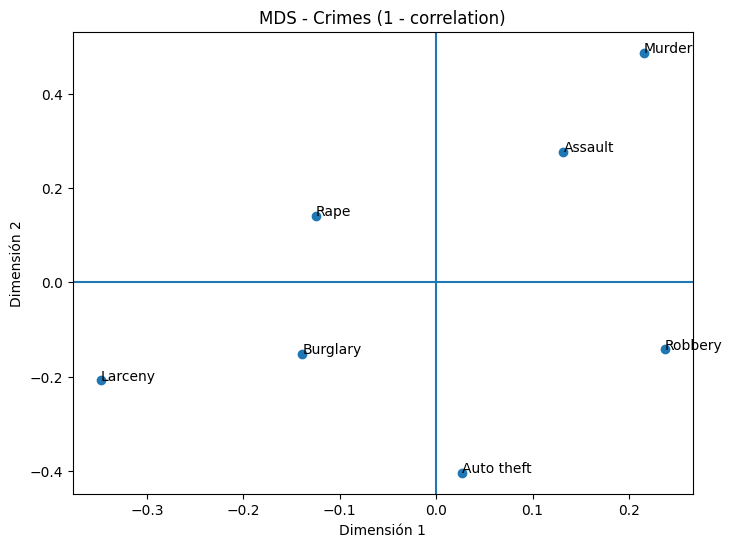

In [11]:
# Graficar
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(coords[:,0], coords[:,1])

for i, name in enumerate(crime_names):
    plt.text(coords[i,0], coords[i,1], name)

plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.title("MDS - Crimes (1 - correlation)")
plt.axhline(0)
plt.axvline(0)
plt.show()

### Interpretación de la gráfica

**Grupo de delitos violentos**
- Murder
- Assault
- Rape

Estos delitos aparecen cercanos entre sí, indicando alta correlación en su ocurrencia.

**Grupo de delitos contra la propiedad**
- Burglary
- Larceny
- Auto theft

También aparecen relativamente agrupados, lo que sugiere que tienden a comportarse de manera similar entre estados.


**Delito intermedio**
- Robbery

Robbery aparece en una posición intermedia.
Esto es razonable, ya que el robo combina elementos de:
- Violencia
- Apropiación de propiedad

Por lo tanto, actúa como puente entre ambos grupos.


**Interpretación del eje principal (Dimensión 1)**

La primera dimensión separa principalmente:
- A la derecha → delitos más violentos (Murder, Assault)
- A la izquierda → delitos contra propiedad (Larceny, Burglary)

Por lo tanto, el eje principal puede interpretarse como: Nivel de violencia del delito

### Conclusión

El MDS permite visualizar claramente la estructura de correlación entre los distintos tipos de delitos. La primera dimensión distingue entre delitos violentos y delitos contra la propiedad, mientras que la segunda dimensión captura diferencias adicionales dentro de cada grupo.
